In [4]:
# pip show matplotlib

# Name: matplotlib
# Version: 3.10.7
# Summary: Python plotting package

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

In [6]:
df = pd.read_csv('2_df.csv')

In [9]:
df.columns

Index(['property_title', 'avg_price', 'possession', 'seller_label',
       'seller_subtitle', 'project', 'single_price', 'builtup_area',
       '1 BHK Flat_min', '1 BHK Flat_max', '2 BHK Flat_min', '2 BHK Flat_max',
       '3 BHK Flat_min', '3 BHK Flat_max', '50 sq.yd Plot_min',
       '50 sq.yd Plot_max', '55 sq.yd Plot_min', '55 sq.yd Plot_max',
       '58 sq.yd Plot_min', '58 sq.yd Plot_max', '60 sq.yd Plot_min',
       '60 sq.yd Plot_max', '70 sq.yd Plot_min', '70 sq.yd Plot_max',
       '83 sq.yd Plot_min', '83 sq.yd Plot_max', '90 sq.yd Plot_min',
       '90 sq.yd Plot_max', '92 sq.yd Plot_min', '92 sq.yd Plot_max',
       '100 sq.yd Plot_min', '100 sq.yd Plot_max', '105 sq.yd Plot_min',
       '105 sq.yd Plot_max', '128 sq.yd Plot_min', '128 sq.yd Plot_max',
       '133 sq.yd Plot_min', '133 sq.yd Plot_max', '135 sq.yd Plot_min',
       '135 sq.yd Plot_max', '143 sq.yd Plot_min', '143 sq.yd Plot_max',
       '145 sq.yd Plot_min', '145 sq.yd Plot_max', '150 sq.yd Plot_min',
     

## 1️⃣ Histogram: Price Distribution
### Understand market-wide pricing spread.

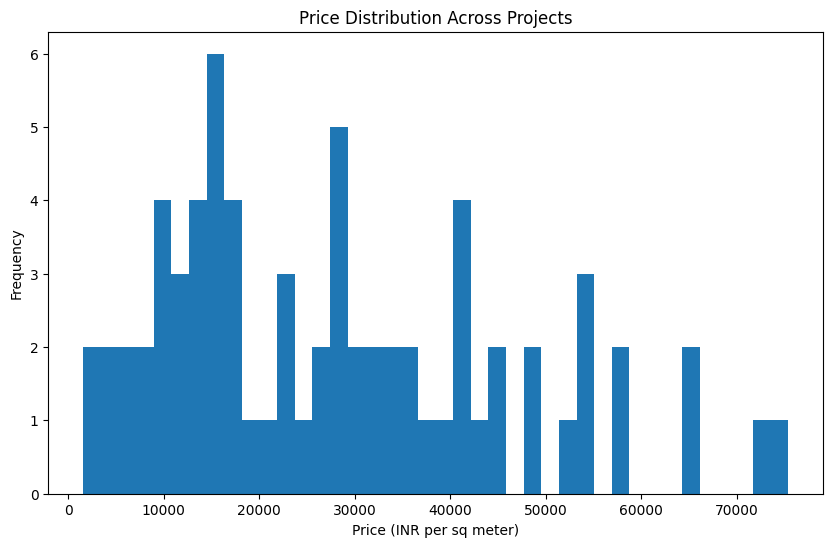

In [ ]:
plt.figure(figsize=(10,6))
df['avg_price_inr_per_sqm'].dropna().plot(kind='hist', bins=40)
plt.xlabel("Price (INR per sq meter)")
plt.ylabel("Frequency")
plt.title("Price Distribution Across Projects")
plt.show()


## 2️⃣ Scatter Plot: Area vs Price
### Reveal anomalies (small units priced higher, plots cheaper, etc.)

Points to plot: 0


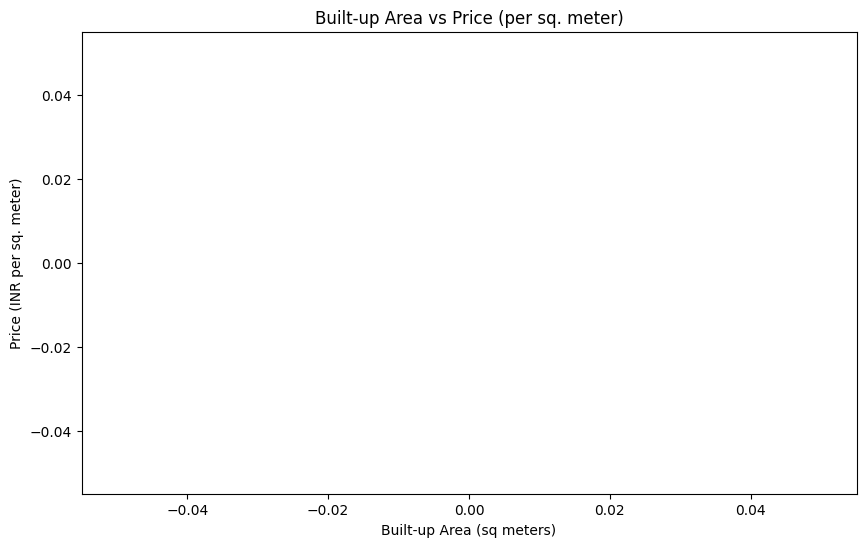

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure numeric types
df['builtup_area_m2'] = pd.to_numeric(df['builtup_area_m2'], errors='coerce')
df['avg_price_inr_per_sqm'] = pd.to_numeric(df['avg_price_inr_per_sqm'], errors='coerce')

# Filter valid rows (must have both values)
plot_df = df.dropna(subset=['builtup_area_m2', 'avg_price_inr_per_sqm'])

# Safety check: show how many points will be plotted
print("Points to plot:", len(plot_df))

plt.figure(figsize=(10,6))
plt.scatter(plot_df['builtup_area_m2'], plot_df['avg_price_inr_per_sqm'])
plt.xlabel("Built-up Area (sq meters)")
plt.ylabel("Price (INR per sq. meter)")
plt.title("Built-up Area vs Price (per sq. meter)")
plt.show()

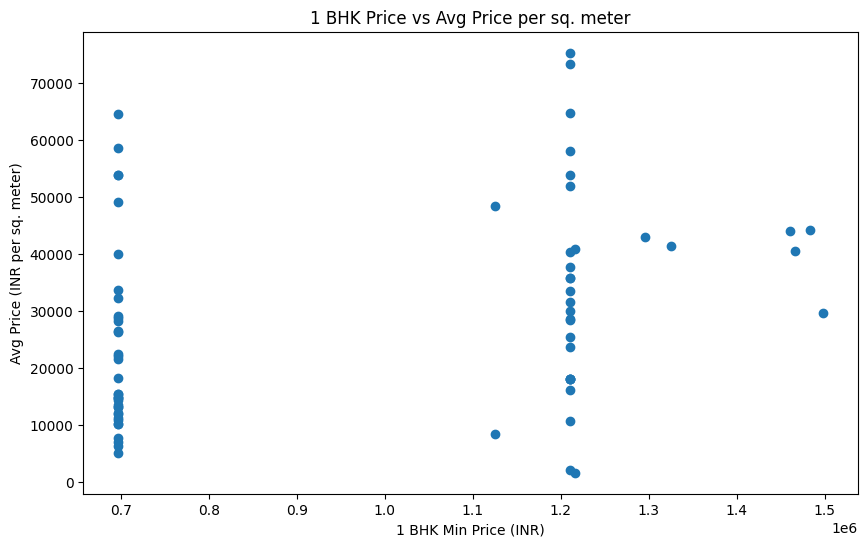

In [ ]:
x = df['1 BHK Flat_min']
y = df['avg_price_inr_per_sqm']

mask = x.notna() & y.notna()

plt.figure(figsize=(10, 6))
plt.scatter(x[mask], y[mask])
plt.xlabel("1 BHK Min Price (INR)")
plt.ylabel("Avg Price (INR per sq. meter)")
plt.title("1 BHK Price vs Avg Price per sq. meter")
plt.show()


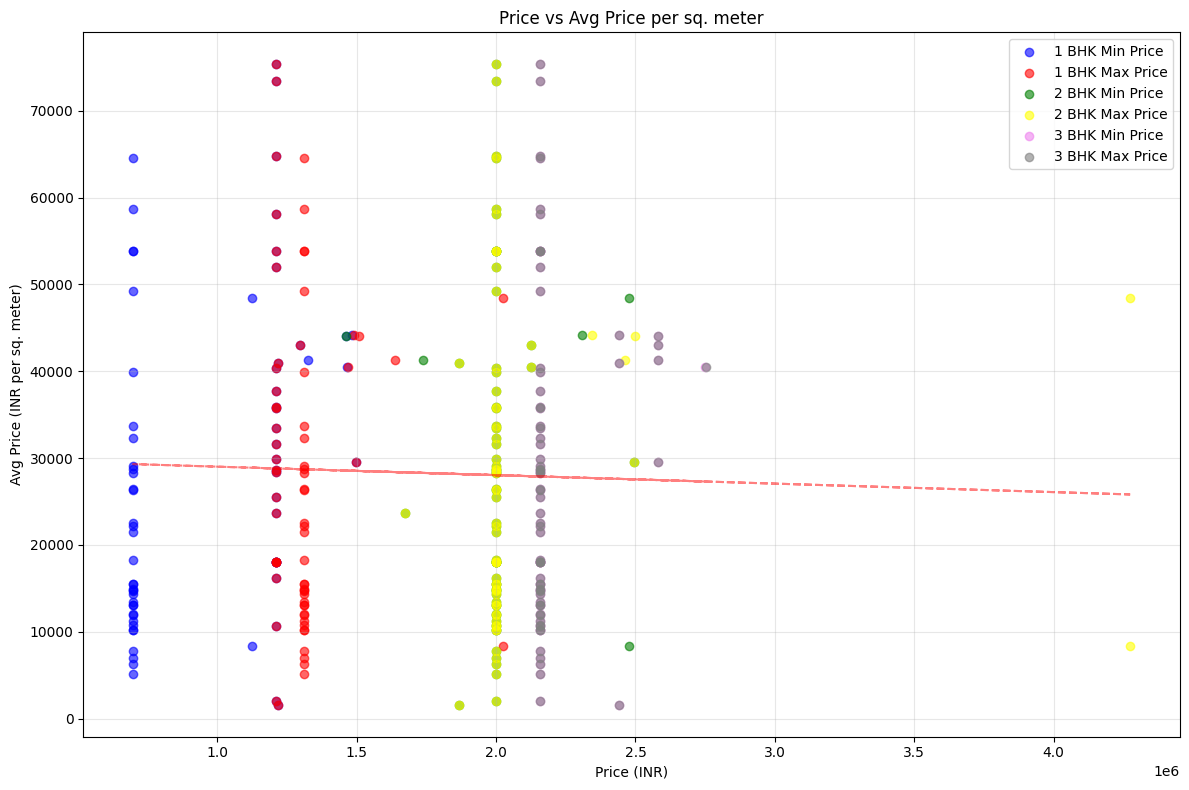

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Create a new figure
plt.figure(figsize=(12, 8))

# Define the columns to plot
columns = ['1 BHK Flat_min', '1 BHK Flat_max', '2 BHK Flat_min', '2 BHK Flat_max', '3 BHK Flat_min', '3 BHK Flat_max']
colors = ['blue', 'red', 'green', 'yellow', 'violet', 'grey']
labels = ['1 BHK Min Price', '1 BHK Max Price', '2 BHK Min Price', '2 BHK Max Price', '3 BHK Min Price', '3 BHK Max Price']

# Plot each column against avg_price_inr_per_sqm
for col, color, label in zip(columns, colors, labels):
    # Create a mask for non-null values in both columns
    mask = df[col].notna() & df['avg_price_inr_per_sqm'].notna()
    
    # Create scatter plot
    plt.scatter(
        df.loc[mask, col], 
        df.loc[mask, 'avg_price_inr_per_sqm'],
        alpha=0.6,
        color=color,
        label=label
    )

# Add labels and title
plt.xlabel("Price (INR)")
plt.ylabel("Avg Price (INR per sq. meter)")
plt.title("Price vs Avg Price per sq. meter")
plt.legend()
plt.grid(True, alpha=0.3)

# Add a trend line for better visualization
x = df[columns].values.flatten()
y = np.tile(df['avg_price_inr_per_sqm'].values, len(columns))
mask = ~np.isnan(x) & ~np.isnan(y)
if mask.any():
    z = np.polyfit(x[mask], y[mask], 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), "r--", alpha=0.5)

plt.tight_layout()
plt.show()

## 3️⃣ Compare 1/2/3 BHK price ranges

### Using your actual columns:

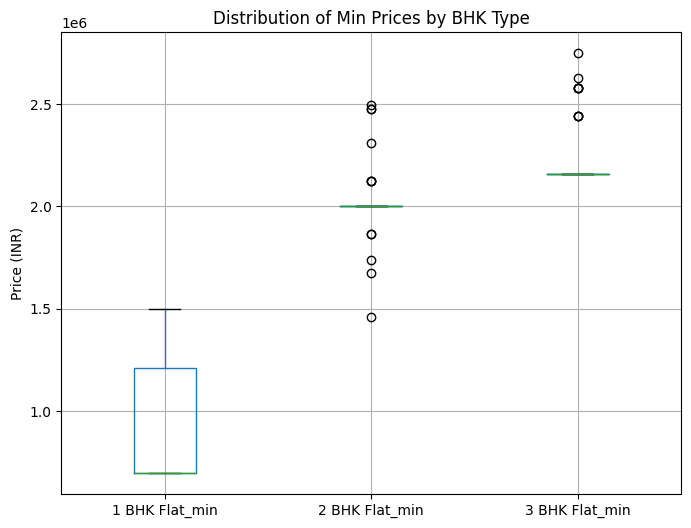

In [12]:
bhk_cols = ['1 BHK Flat_min', '2 BHK Flat_min', '3 BHK Flat_min']

plt.figure(figsize=(8, 6))
df[bhk_cols].dropna(how='all').boxplot()
plt.ylabel("Price (INR)")
plt.title("Distribution of Min Prices by BHK Type")
plt.show()


## 4️⃣ Project-wise average avg_price_inr_per_sqm (Top 15 projects)

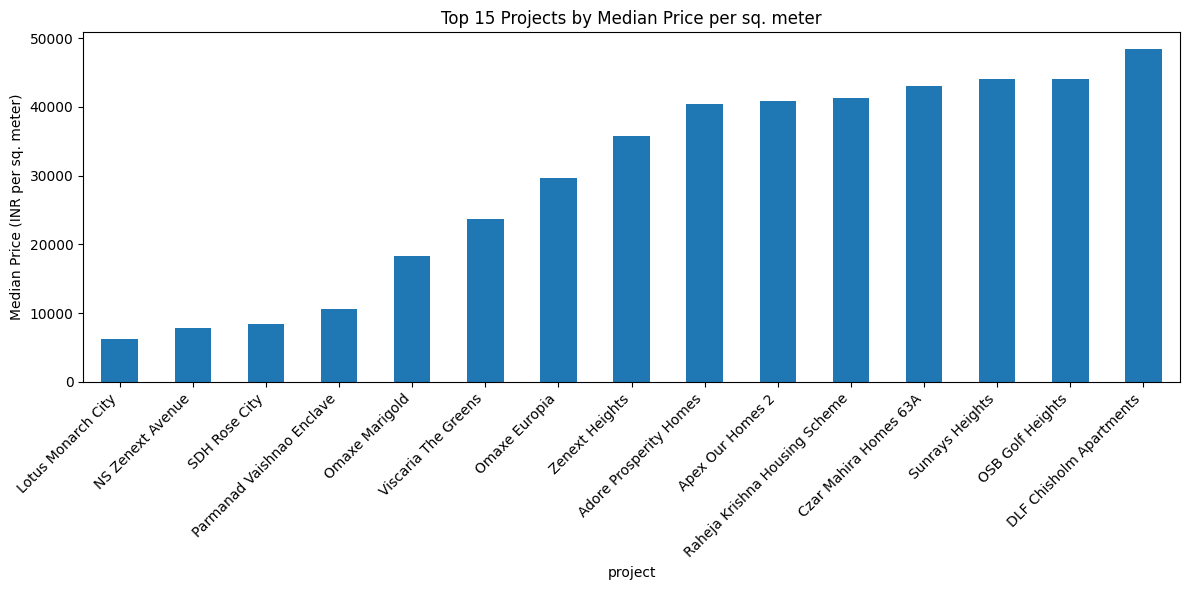

In [13]:
proj_price = (
    df.groupby('project')['avg_price_inr_per_sqm']
      .median()
      .dropna()
      .sort_values()
)

top_projects = proj_price.tail(15)  # 15 most expensive

plt.figure(figsize=(12, 6))
top_projects.plot(kind='bar')
plt.ylabel("Median Price (INR per sq. meter)")
plt.title("Top 15 Projects by Median Price per sq. meter")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 5️⃣ Outlier highlight on Area vs Price

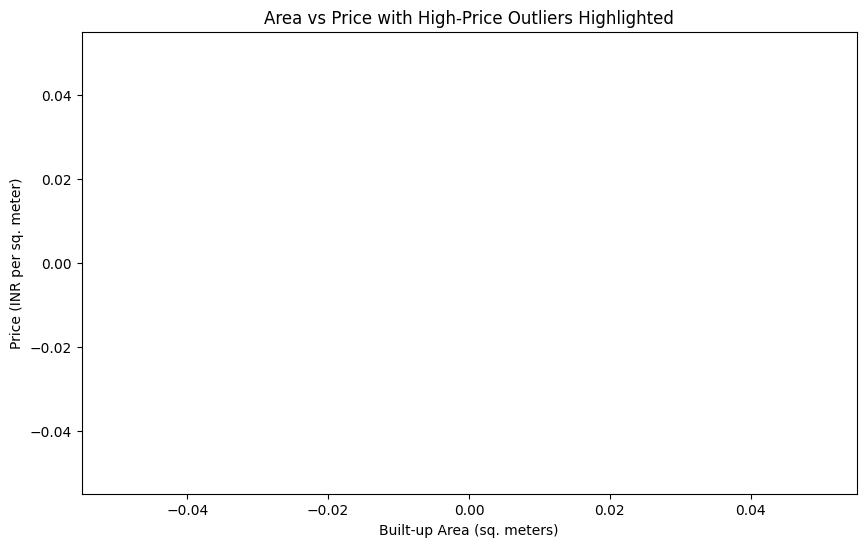

In [14]:
threshold = df['avg_price_inr_per_sqm'].quantile(0.95)
is_outlier = df['avg_price_inr_per_sqm'] > threshold

plt.figure(figsize=(10, 6))
plt.scatter(df['builtup_area_m2'], df['avg_price_inr_per_sqm'], alpha=0.5)
plt.scatter(
    df.loc[is_outlier, 'builtup_area_m2'],
    df.loc[is_outlier, 'avg_price_inr_per_sqm'],
    s=80,
)
plt.xlabel("Built-up Area (sq. meters)")
plt.ylabel("Price (INR per sq. meter)")
plt.title("Area vs Price with High-Price Outliers Highlighted")
plt.show()


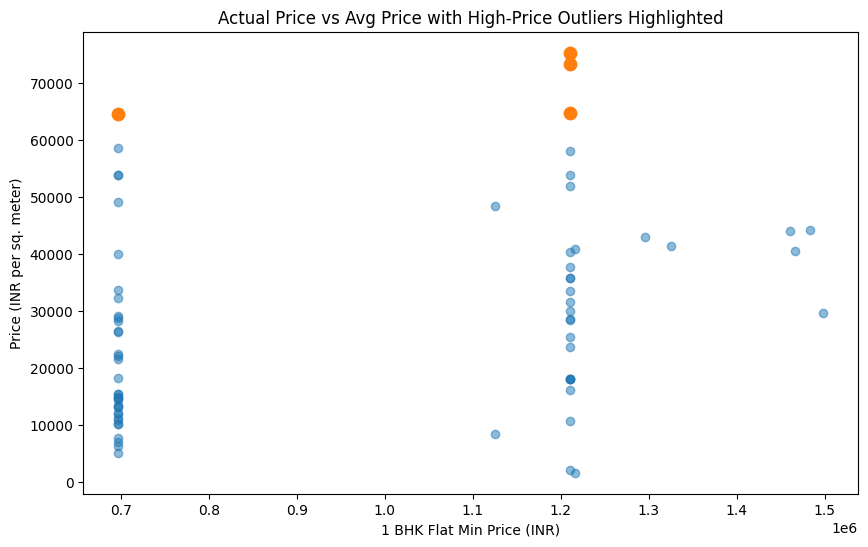

In [25]:
threshold = df['avg_price_inr_per_sqm'].quantile(0.95)
is_outlier = df['avg_price_inr_per_sqm'] > threshold

plt.figure(figsize=(10, 6))
plt.scatter(df['1 BHK Flat_min'], df['avg_price_inr_per_sqm'], alpha=0.5)
plt.scatter(
    df.loc[is_outlier, '1 BHK Flat_min'],
    df.loc[is_outlier, 'avg_price_inr_per_sqm'],
    s=80,
)
plt.xlabel("1 BHK Flat Min Price (INR)")
plt.ylabel("Price (INR per sq. meter)")
plt.title("Actual Price vs Avg Price with High-Price Outliers Highlighted")
plt.show()

## 6️⃣ Simple count of listings per project (top 20)

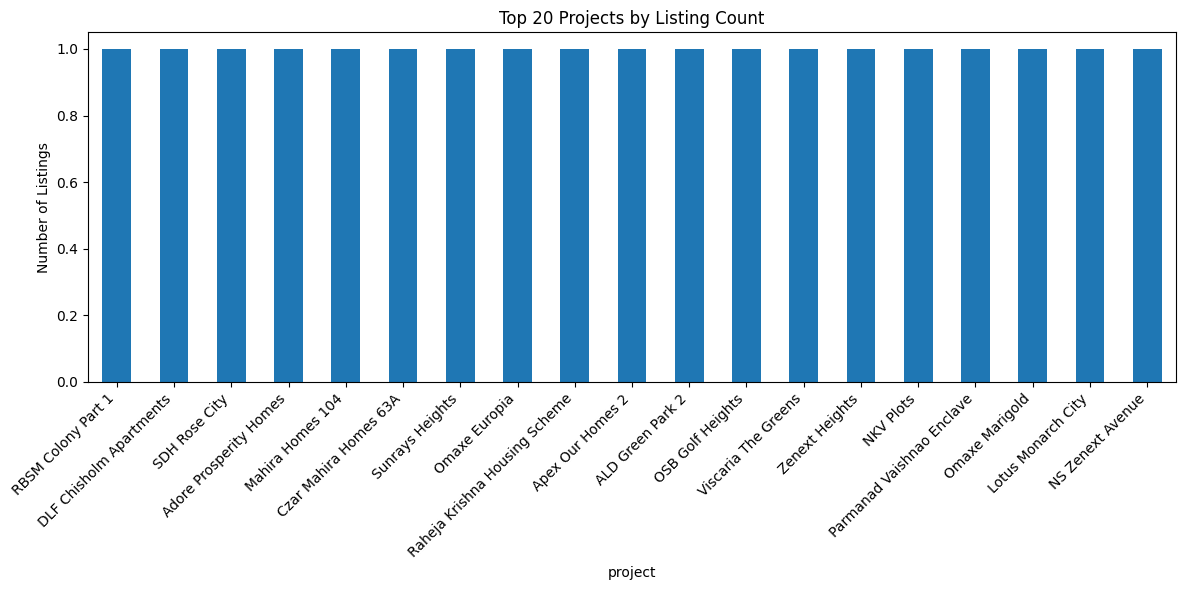

In [15]:
counts = df['project'].value_counts().head(20)

plt.figure(figsize=(12, 6))
counts.plot(kind='bar')
plt.ylabel("Number of Listings")
plt.title("Top 20 Projects by Listing Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
